# this is running the estimator for the pz challenge taskset 2

In [2]:
import sklearn
from packaging import version
from sklearn.model_selection import train_test_split

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [3]:
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

2026-09-11 09:06:52.307548: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-11 09:06:52.307594: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-11 09:06:52.309478: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-11 09:06:52.320037: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-11 09:06:54.135432: W tensorflow/compiler/tf2

In [4]:
import matplotlib.pyplot as plt

plt.rc("font", size=14)
plt.rc("axes", labelsize=14, titlesize=14)
plt.rc("legend", fontsize=14)
plt.rc("xtick", labelsize=10)
plt.rc("ytick", labelsize=10)

In [5]:
import h5py
import numpy as np
import pandas as pd

In [6]:
import cnnpz

# predefined functions

## Load training and test data, filter curves

In [7]:
saveroot = "/pscratch/sd/q/qhang/pz_datachllenge_data/"
sims = ["cardinal", "flagship"]
Yrs = [1, 10]
test_dataset_taskset2 = {}
for sim in sims:
    test_dataset_taskset2[sim] = {}
    for Yr in Yrs:
        fname = saveroot + f"pz_challenge_taskset_2_{sim}_test_{Yr}yr.hdf5"
        with h5py.File(fname, "r") as f:
            data = {key: f[key][:] for key in f.keys()}
        test_dataset_taskset2[sim][Yr] = pd.DataFrame(data)

train_dataset_taskset2 = {}
for sim in sims:
    train_dataset_taskset2[sim] = {}
    for Yr in Yrs:
        fname = saveroot + f"pz_challenge_taskset_2_{sim}_training_{Yr}yr.hdf5"
        with h5py.File(fname, "r") as f:
            data = {key: f[key][:] for key in f.keys()}
        train_dataset_taskset2[sim][Yr] = pd.DataFrame(data)

Text(0, 0.5, 'r-i')

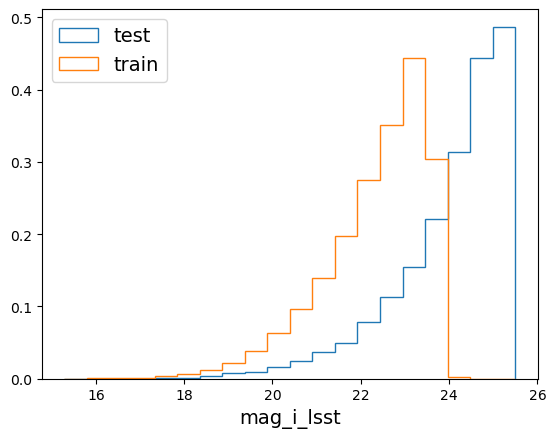

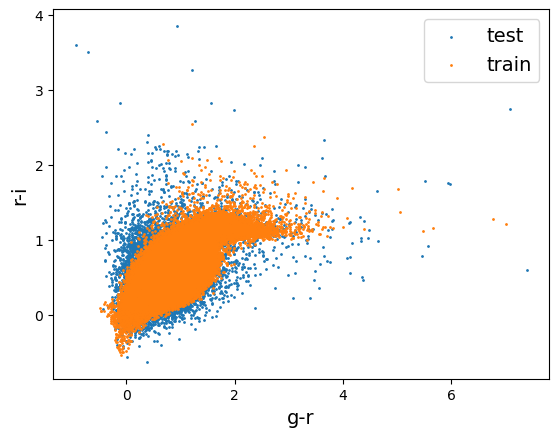

In [8]:
train = train_dataset_taskset2["cardinal"][10]
test = test_dataset_taskset2["cardinal"][10]

plt.figure()
cc = plt.hist(test["mag_i_lsst"], bins=20, histtype="step", density=True, label="test")
cc = plt.hist(train["mag_i_lsst"], bins=cc[1], histtype="step", density=True, label="train")
plt.legend()
plt.xlabel("mag_i_lsst")

plt.figure()
plt.scatter(test["mag_g_lsst"] - test["mag_r_lsst"], test["mag_r_lsst"] - test["mag_i_lsst"], c="C0", s=1, label="test")
plt.scatter(
    train["mag_g_lsst"] - train["mag_r_lsst"], train["mag_r_lsst"] - train["mag_i_lsst"], c="C1", s=1, label="train"
)
plt.legend()
plt.xlabel("g-r")
plt.ylabel("r-i")

In [19]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dec              20000 non-null  float64
 1   mag_H_roman      20000 non-null  float64
 2   mag_H_roman_err  20000 non-null  float64
 3   mag_J_roman      20000 non-null  float64
 4   mag_J_roman_err  20000 non-null  float64
 5   mag_Y_roman      20000 non-null  float64
 6   mag_Y_roman_err  20000 non-null  float64
 7   mag_g_lsst       19941 non-null  float64
 8   mag_g_lsst_err   19941 non-null  float64
 9   mag_i_lsst       20000 non-null  float64
 10  mag_i_lsst_err   20000 non-null  float64
 11  mag_r_lsst       19998 non-null  float64
 12  mag_r_lsst_err   19998 non-null  float64
 13  mag_u_lsst       17770 non-null  float64
 14  mag_u_lsst_err   17770 non-null  float64
 15  mag_y_lsst       19951 non-null  float64
 16  mag_y_lsst_err   19951 non-null  float64
 17  mag_z_lsst  

In [10]:
pre_training_popcosmos = pd.read_parquet(
    "/pscratch/sd/q/qhang/pop-cosmos-data/mock_catalog_Ch1_26.degrade_lsst_y10.parquet"
)

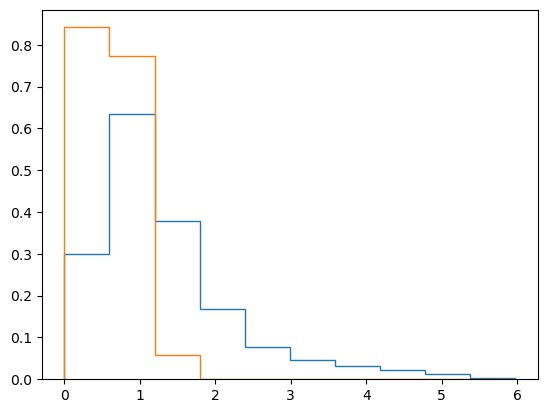

In [11]:
cc = plt.hist(pre_training_popcosmos["redshift"], density=True, histtype="step")
cc = plt.hist(train["redshift"], bins=cc[1], density=True, histtype="step")

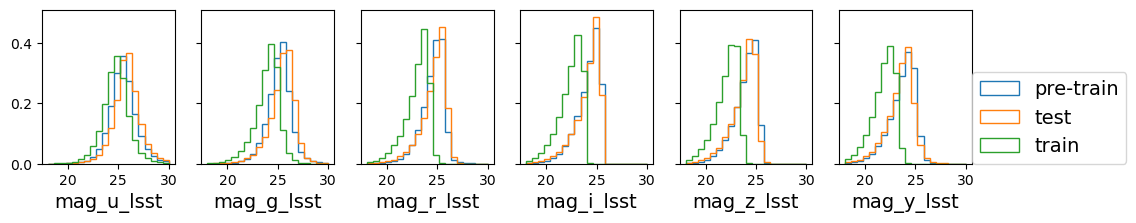

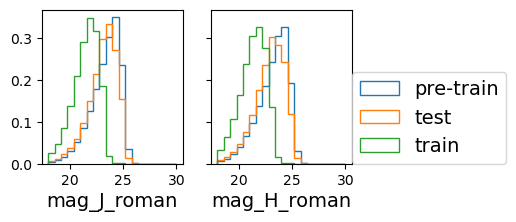

In [12]:
fig, axarr = plt.subplots(1, 6, figsize=[12, 2], sharey=True)
for i, band in enumerate("ugrizy"):
    plt.sca(axarr[i])
    cc = plt.hist(
        pre_training_popcosmos[f"mag_{band}_lsst"],
        bins=20,
        range=[18, 30],
        histtype="step",
        density=True,
        label="pre-train",
    )
    cc = plt.hist(test[f"mag_{band}_lsst"], bins=cc[1], histtype="step", density=True, label="test")
    cc = plt.hist(train[f"mag_{band}_lsst"], bins=cc[1], histtype="step", density=True, label="train")
    plt.xlabel(f"mag_{band}_lsst")
plt.legend(loc=(1, 0))

fig, axarr = plt.subplots(1, 2, figsize=[4, 2], sharey=True)
for i, band in enumerate("JH"):
    plt.sca(axarr[i])
    cc = plt.hist(
        pre_training_popcosmos[f"mag_{band}_roman"],
        bins=20,
        range=[18, 30],
        histtype="step",
        density=True,
        label="pre-train",
    )
    cc = plt.hist(test[f"mag_{band}_roman"], bins=cc[1], histtype="step", density=True, label="test")
    cc = plt.hist(train[f"mag_{band}_roman"], bins=cc[1], histtype="step", density=True, label="train")
    plt.xlabel(f"mag_{band}_roman")
plt.legend(loc=(1, 0))

In [13]:
def plot_contour(x, y, cmap="Reds"):
    counts, xedges, yedges = np.histogram2d(x, y, bins=50, range=[[-1, 2], [-1, 2]])
    # Convert bin edges to bin centers (needed for contour plotting)
    xcenters = (xedges[:-1] + xedges[1:]) / 2
    ycenters = (yedges[:-1] + yedges[1:]) / 2

    # histogram2d returns counts as [x_bins, y_bins], but contour expects [rows, cols] = [y, x]
    Z = counts.T

    threshold = 0.1 * Z.max()
    levels = np.linspace(threshold, 0.5 * Z.max(), 5)
    # Plot
    plt.contourf(xcenters, ycenters, Z, levels=levels, cmap=cmap)

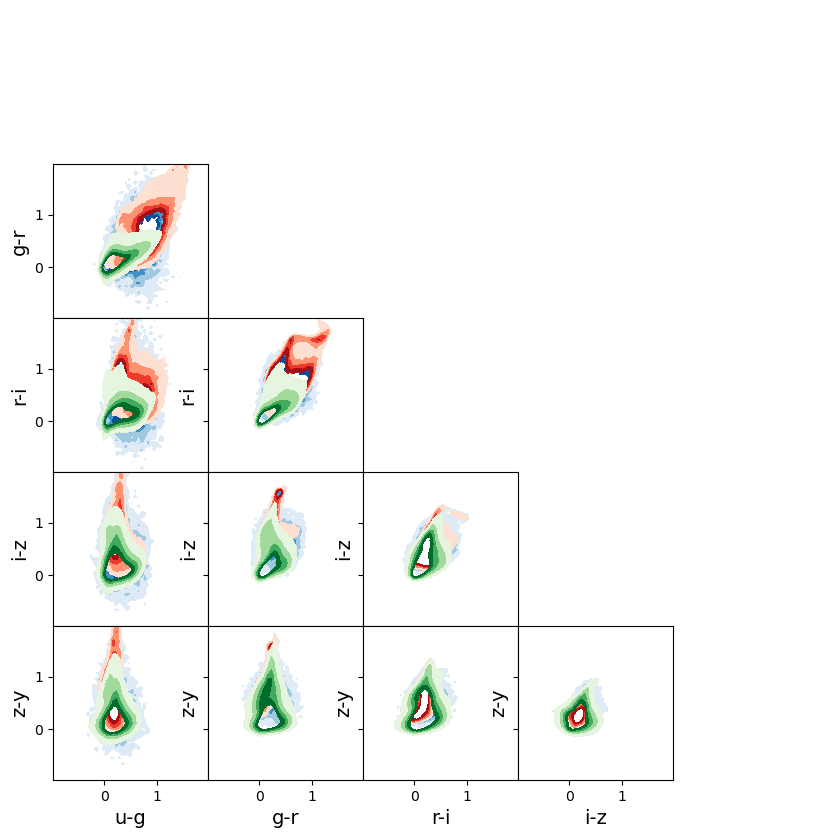

In [14]:
# color
fig, axarr = plt.subplots(5, 5, figsize=[10, 10], sharex=True, sharey=True)
bands = "ugrizy"
for i in range(5):
    for j in range(5):
        if i <= j:
            axarr[i, j].axis("off")
        else:
            plt.sca(axarr[i, j])
            x = test[f"mag_{bands[i]}_lsst"] - test[f"mag_{bands[i+1]}_lsst"]
            y = test[f"mag_{bands[j]}_lsst"] - test[f"mag_{bands[j+1]}_lsst"]
            plot_contour(x, y, cmap="Blues")

            x = train[f"mag_{bands[i]}_lsst"] - train[f"mag_{bands[i+1]}_lsst"]
            y = train[f"mag_{bands[j]}_lsst"] - train[f"mag_{bands[j+1]}_lsst"]
            plot_contour(x, y, cmap="Reds")

            x = pre_training_popcosmos[f"mag_{bands[i]}_lsst"] - pre_training_popcosmos[f"mag_{bands[i+1]}_lsst"]
            y = pre_training_popcosmos[f"mag_{bands[j]}_lsst"] - pre_training_popcosmos[f"mag_{bands[j+1]}_lsst"]
            plot_contour(x, y, cmap="Greens")

            plt.ylabel(f"{bands[i]}-{bands[i+1]}")
            plt.xlabel(f"{bands[j]}-{bands[j+1]}")

plt.subplots_adjust(wspace=0, hspace=0)

### reweight to get similar colour? - will do this in a separate notebook




[1.         0.79840819 0.2569272  0.30697679 0.15989882 0.14162824
 0.29949479 0.56854753 0.83421722 1.         0.95445846 0.76622186
 0.78027139 0.58855348 0.47532982 0.51626719 0.44683687 0.51331383
 0.28849235 0.33256693]


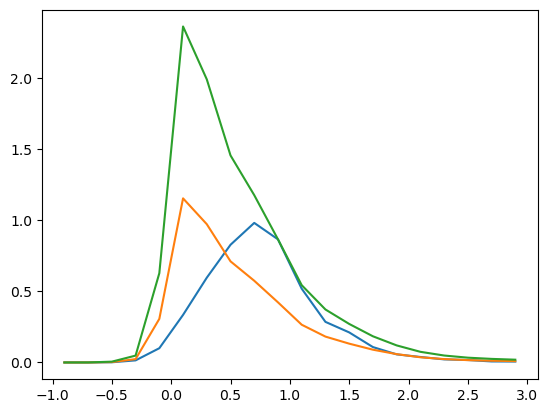

In [15]:
# for now, we can just reweight g-r colour:
bands = "ugrizy"
i = 1
x1 = test[f"mag_{bands[i]}_lsst"] - test[f"mag_{bands[i+1]}_lsst"]
cc1 = np.histogram(x1, bins=20, density=True, range=[-1, 3])
xx = (cc1[1][1:] + cc1[1][:-1]) / 2.0

# x = train[f'mag_{bands[i]}_lsst'] - train[f'mag_{bands[i+1]}_lsst']
# cc = plt.hist(x, bins=cc[1], density=True)

x2 = pre_training_popcosmos[f"mag_{bands[i]}_lsst"] - pre_training_popcosmos[f"mag_{bands[i+1]}_lsst"]
cc2 = np.histogram(x2, bins=cc1[1], density=True)

# now make a naive scaling:
plt.plot(xx, cc1[0])
plt.plot(xx, cc2[0])

r = cc1[0][9] / cc2[0][9]
plt.plot(xx, cc2[0] * r)
frac = cc1[0] / (cc2[0] * r)
frac[frac > 1] = 1
print(frac)

# now do the selection:
match_color_index = np.array([])
for i in range(len(xx)):
    sel1 = np.where((x2 >= cc1[1][i]) & (x2 < cc1[1][i + 1]))[0]
    if frac[i] < 1:
        # sub sample:
        random_ = np.random.uniform(size=len(sel1))
        sel2 = random_ < frac[i]
        sel1 = sel1[sel2]
    match_color_index = np.append(match_color_index, sel1)
match_color_index = np.sort((match_color_index).astype(int))

pre_training_cut = pre_training_popcosmos.loc[match_color_index]
pre_training_cut = pre_training_cut.reset_index(drop=True)

In [16]:
len(pre_training_cut)

492279

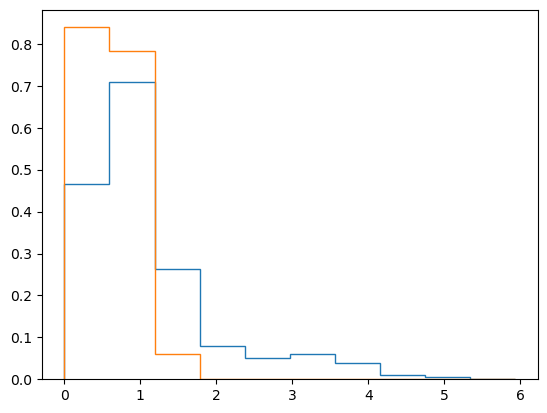

In [17]:
cc = plt.hist(pre_training_cut["redshift"], density=True, histtype="step")
cc = plt.hist(train["redshift"], bins=cc[1], density=True, histtype="step")

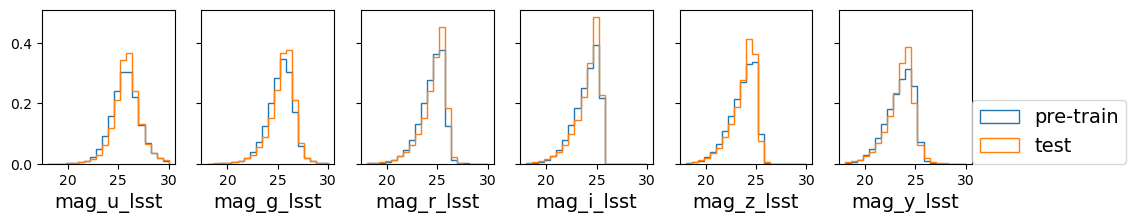

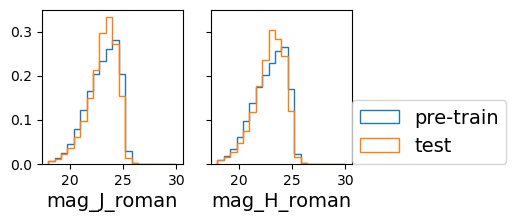

In [18]:
fig, axarr = plt.subplots(1, 6, figsize=[12, 2], sharey=True)
for i, band in enumerate("ugrizy"):
    plt.sca(axarr[i])
    cc = plt.hist(
        pre_training_cut[f"mag_{band}_lsst"], bins=20, range=[18, 30], histtype="step", density=True, label="pre-train"
    )
    cc = plt.hist(test[f"mag_{band}_lsst"], bins=cc[1], histtype="step", density=True, label="test")
    # cc=plt.hist(train[f'mag_{band}_lsst'], bins=cc[1],histtype='step', density=True, label='train')
    plt.xlabel(f"mag_{band}_lsst")
plt.legend(loc=(1, 0))

fig, axarr = plt.subplots(1, 2, figsize=[4, 2], sharey=True)
for i, band in enumerate("JH"):
    plt.sca(axarr[i])
    cc = plt.hist(
        pre_training_cut[f"mag_{band}_roman"], bins=20, range=[18, 30], histtype="step", density=True, label="pre-train"
    )
    cc = plt.hist(test[f"mag_{band}_roman"], bins=cc[1], histtype="step", density=True, label="test")
    # cc=plt.hist(train[f'mag_{band}_roman'], bins=cc[1],histtype='step', density=True, label='train')
    plt.xlabel(f"mag_{band}_roman")
plt.legend(loc=(1, 0))

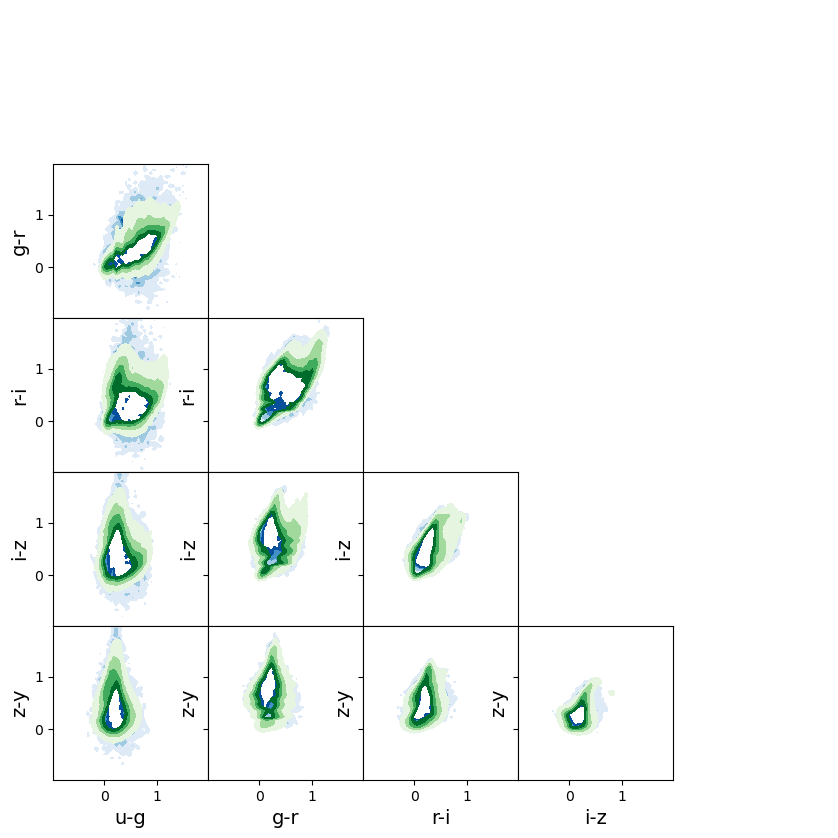

In [19]:
fig, axarr = plt.subplots(5, 5, figsize=[10, 10], sharex=True, sharey=True)
bands = "ugrizy"
for i in range(5):
    for j in range(5):
        if i <= j:
            axarr[i, j].axis("off")
        else:
            plt.sca(axarr[i, j])
            x = test[f"mag_{bands[i]}_lsst"] - test[f"mag_{bands[i+1]}_lsst"]
            y = test[f"mag_{bands[j]}_lsst"] - test[f"mag_{bands[j+1]}_lsst"]
            plot_contour(x, y, cmap="Blues")

            # x = train[f'mag_{bands[i]}_lsst'] - train[f'mag_{bands[i+1]}_lsst']
            # y = train[f'mag_{bands[j]}_lsst'] - train[f'mag_{bands[j+1]}_lsst']
            # plot_contour(x, y, cmap="Reds")

            x = pre_training_cut[f"mag_{bands[i]}_lsst"] - pre_training_cut[f"mag_{bands[i+1]}_lsst"]
            y = pre_training_cut[f"mag_{bands[j]}_lsst"] - pre_training_cut[f"mag_{bands[j+1]}_lsst"]
            plot_contour(x, y, cmap="Greens")

            plt.ylabel(f"{bands[i]}-{bands[i+1]}")
            plt.xlabel(f"{bands[j]}-{bands[j+1]}")

plt.subplots_adjust(wspace=0, hspace=0)

Let's start with this pre-training sample

In [20]:
# get the LSST and roman filter curves:
filter_root = "/global/homes/q/qhang/desc/rail_base/src/rail/examples_data/estimation_data/data/FILTER/"

wave = {
    "Y": 106,
    "J": 129,
    "H": 158,
}
lsst_filter_curves = {}
roman_filter_curves = {}
for b in "ugrizy":
    lsst_filter_curves[b] = np.loadtxt(filter_root + f"DC2LSST_{b}.res")

for b in "YJH":
    roman_filter_curves[b] = np.loadtxt(filter_root + f"roman_{b}{wave[b]}.res")

# define the wavelength grid
# to begin with, use blocks rather than filter curves
lambda_min = lsst_filter_curves["u"][:, 0].min()
lambda_max = roman_filter_curves["H"][:, 0].max()
print(lambda_min, lambda_max)

lambda_array = np.linspace(lambda_min, lambda_max, 31)
# now let's conver filter curves to blocks: here let's also ignore the big Y band as it overlaps with the y band

3000.0 18650.0


### Transform data, make X_train, Y_train, and test dataset, variants of this dataset

In [21]:
bin_edges = {}
for b in "ugrizyJH":
    if b not in "JH":
        bin_edges[b] = cnnpz.get_bin_edges(lsst_filter_curves[b][:, 0])
    else:
        bin_edges[b] = cnnpz.get_bin_edges(roman_filter_curves[b][:, 0])
new_edges = lambda_array

rebinned_filters = {}
for b in "ugrizyJH":
    if b not in "JH":
        counts = lsst_filter_curves[b][:, 1]
    else:
        counts = roman_filter_curves[b][:, 1]
    rebinned_filters[b] = cnnpz.rebin_filter(bin_edges[b], counts, new_edges)

lambda_array_cen = (new_edges[1:] + new_edges[:-1]) / 2
dlambda = new_edges[1] - new_edges[0]
# for b in "ugrizyJH":
#  plt.plot(lambda_array_cen, rebinned_filters[b],'.-')

# further convert this to blocks:
# let's take 1 when the current filter value is > next filter
filter_blocks = {}
bands = "ugrizyJH"
for i, b in enumerate("ugrizyJ"):
    if i > 0:
        filter_blocks[b] = (rebinned_filters[b] >= rebinned_filters[bands[i + 1]]) & (
            rebinned_filters[b] > rebinned_filters[bands[i - 1]]
        )
    else:
        filter_blocks[b] = rebinned_filters[b] > rebinned_filters[bands[i + 1]]
filter_blocks["H"] = (rebinned_filters["H"] > rebinned_filters["J"]) & (rebinned_filters["H"] > rebinned_filters["y"])

# Pre-training with pop cosmos mock data

In [22]:
# split pop cosmos data to training and test set:
# first, let's pick some missing bands randomly:
threshold = [27, 27, 25.5, 25, 25]
for i, band in enumerate("ugrzy"):
    mask_above = pre_training_cut[f"mag_{band}_lsst"] > threshold[i]  # rows above threshold
    rand_mask = np.random.rand(len(pre_training_cut)) < 0.10  # True for ~10% of ALL rows
    pre_training_cut.loc[mask_above & rand_mask, f"mag_{band}_lsst"] = np.nan

In [28]:
pre_training_cut = pre_training_cut.reset_index(drop=True)

In [33]:
X, Y = cnnpz.transform_data_to_XY(pre_training_cut, lambda_array_cen, filter_blocks, apply_stretch=False)

pre_training_train, pre_training_test, pre_training_train_Y, pre_training_test_Y = train_test_split(
    X,
    Y,
    test_size=0.2,  # 20% held out for testing
    random_state=42,  # for reproducibility
)

X = pre_training_train
Y = pre_training_train_Y.reset_index(drop=True)

X_test = pre_training_test
Y_test = pre_training_test_Y.reset_index(drop=True)

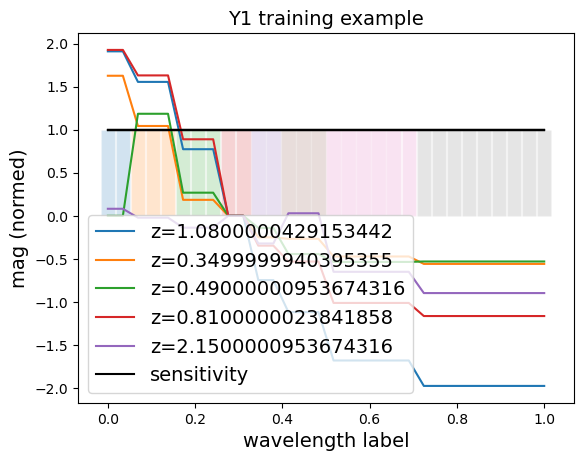

In [34]:
cnnpz.visualize_the_data(X, Y, lambda_array_cen, filter_blocks, title="Y1 training example")

In [78]:
# train
trained_models, histories = cnnpz.train_ensembles(build_model, X, Y)


--- Fold 1/5 ---
Epoch 1/100
1247/1247 - 7s - loss: 0.0151 - val_loss: 0.0022 - lr: 0.0010 - 7s/epoch - 6ms/step
Epoch 2/100
1247/1247 - 5s - loss: 0.0044 - val_loss: 0.0018 - lr: 0.0010 - 5s/epoch - 4ms/step
Epoch 3/100
1247/1247 - 5s - loss: 0.0039 - val_loss: 0.0012 - lr: 0.0010 - 5s/epoch - 4ms/step
Epoch 4/100
1247/1247 - 5s - loss: 0.0035 - val_loss: 0.0012 - lr: 0.0010 - 5s/epoch - 4ms/step
Epoch 5/100
1247/1247 - 5s - loss: 0.0034 - val_loss: 0.0013 - lr: 0.0010 - 5s/epoch - 4ms/step
Epoch 6/100

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1247/1247 - 5s - loss: 0.0030 - val_loss: 0.0028 - lr: 0.0010 - 5s/epoch - 4ms/step
Epoch 7/100
1247/1247 - 5s - loss: 0.0026 - val_loss: 6.7795e-04 - lr: 5.0000e-04 - 5s/epoch - 4ms/step
Epoch 8/100
1247/1247 - 4s - loss: 0.0026 - val_loss: 5.1734e-04 - lr: 5.0000e-04 - 4s/epoch - 4ms/step
Epoch 9/100
1247/1247 - 4s - loss: 0.0026 - val_loss: 5.8013e-04 - lr: 5.0000e-04 - 4s/epoch - 4ms/step
Epoch 10/100
1247

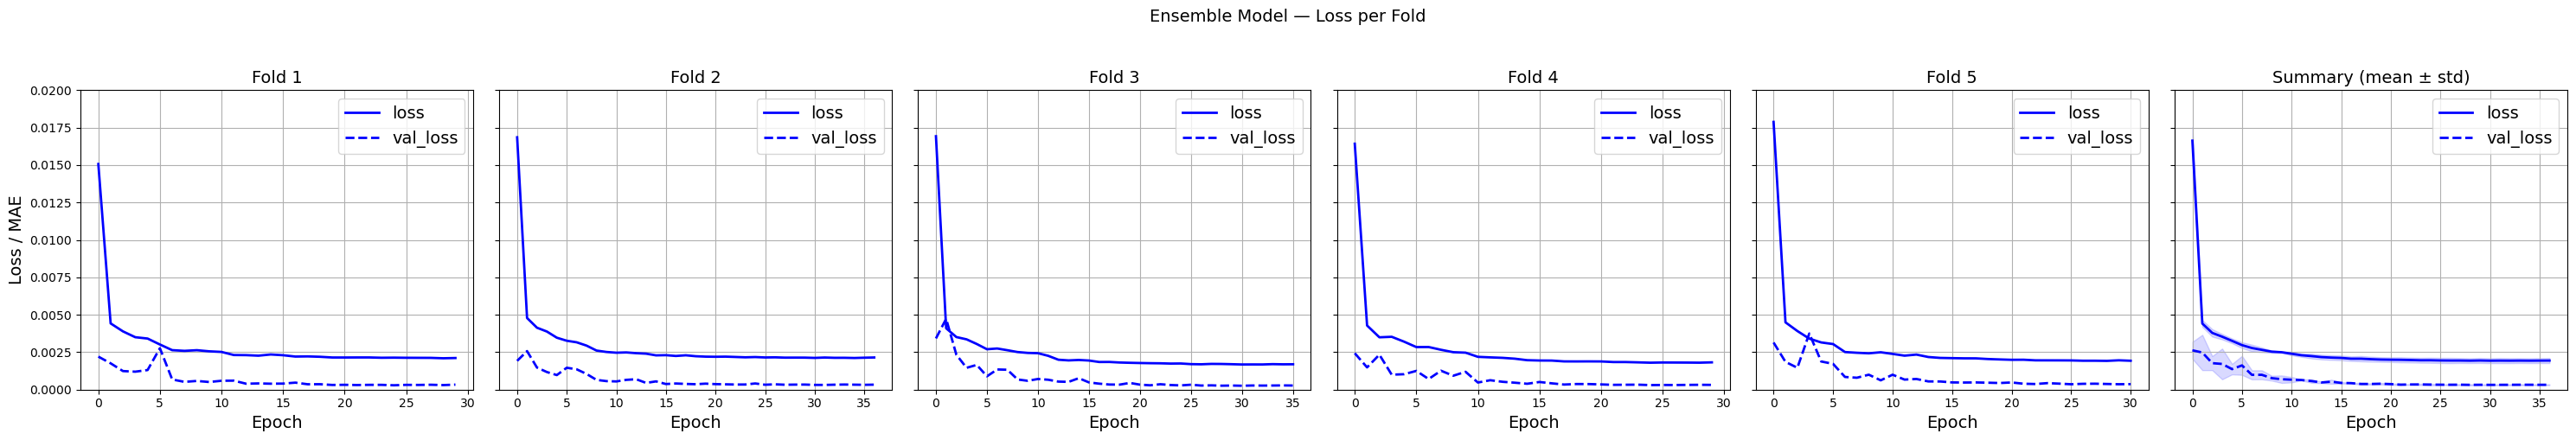

In [80]:
# save the model, check performance:
cnnpz.plot_ensemble_losses(histories, ylim=(0, 0.02))

In [81]:
# save the trained model:
root = "/pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/popcosmos/models"
save_dir = root + "/ensemble_CNN_6layers_missing"
cnnpz.save_ensemble(trained_models, save_dir=save_dir)

Saved fold 1 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/popcosmos/models/ensemble_CNN_6layers_missing/model_fold_1.keras
Saved fold 2 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/popcosmos/models/ensemble_CNN_6layers_missing/model_fold_2.keras
Saved fold 3 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/popcosmos/models/ensemble_CNN_6layers_missing/model_fold_3.keras
Saved fold 4 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/popcosmos/models/ensemble_CNN_6layers_missing/model_fold_4.keras
Saved fold 5 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/popcosmos/models/ensemble_CNN_6layers_missing/model_fold_5.keras
Saved normalisation parameters to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/popcosmos/models/ensemble_CNN_6layers_missing/norm_params.json


In [82]:
y_pred_ensemble, y_pred_STD = cnnpz.ensemble_predict(trained_models, X_test_stretch)

3117/3117 [==============================] - 3s 1ms/step


/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/scipy/stats/_stats_py.py:3666: RuntimeWarning: Mean of empty slice.
  c_mean = c.mean()
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/global/common/softwa

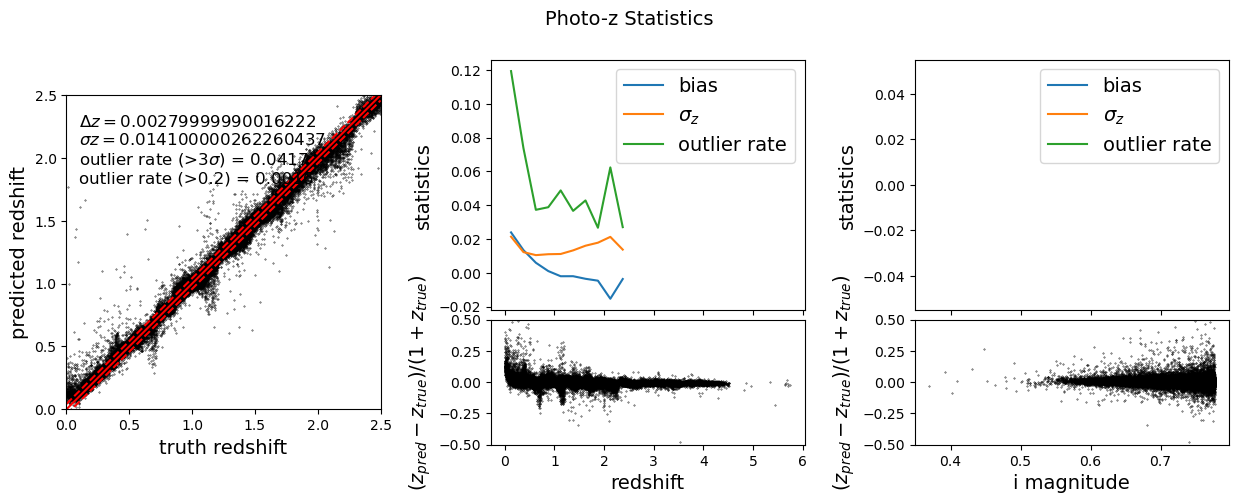

Plot saved to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/popcosmos/models/ensemble_CNN_6layers_missing/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [83]:
redshift_bins = np.linspace(0, 2.5, 11)
imag_bins = np.linspace(18, 25.5, 11)
fname = save_dir + "/stats.pkl"
stats, redshift_stats, imag_stats = cnnpz.get_all_stats(
    Y_test,
    y_pred_ensemble.flatten(),
    pre_training_test[:, 8, 0],
    save=True,
    saveroot=fname,
    redshift_bins=redshift_bins,
    imag_bins=imag_bins,
)

cnnpz.plot_stats(
    stats,
    redshift_stats,
    imag_stats,
    Y_test,
    y_pred_ensemble.flatten(),
    redshift_bins,
    imag_bins,
    pre_training_test[:, 8, 0],
    save_path=save_dir + "/photoz_stats.png",
)

# Cardinal Y1
fine tune on the training sample

In [36]:
training_data = train_dataset_taskset2["cardinal"][1]
test_data = test_dataset_taskset2["cardinal"][1]
# test data has some NULLs while training data does not

In [37]:
# now split training and validation set:
X, Y = cnnpz.transform_data_to_XY(training_data, lambda_array_cen, filter_blocks, apply_stretch=False)
X_test, _ = cnnpz.transform_data_to_XY(test_data, lambda_array_cen, filter_blocks, apply_stretch=False, missingY=True)

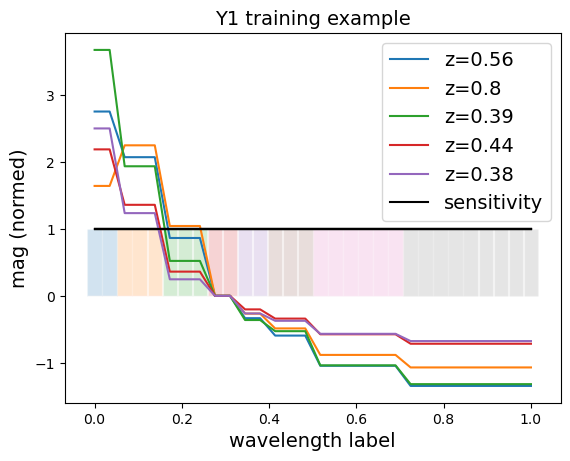

In [39]:
cnnpz.visualize_the_data(X, Y, lambda_array_cen, filter_blocks, title="Y1 training example")

# Fine tune the trained ensemble model

In [100]:
# reserve 10% for checking:
rand_mask = np.random.rand(len(Y.to_numpy())) < 0.10
X_fortrain = X[~rand_mask, :, :]
Y_fortrain = Y.to_numpy()[~rand_mask]

X_forval = X[rand_mask, :, :]
Y_forval = Y.to_numpy()[rand_mask]

X_test = np.copy(X_test)

print(len(Y_fortrain), len(Y_forval), len(X_test))

89964 10036 20000


In [ ]:
trained_models, histories = cnnpz.fine_tune_pre_trained_model(
    X_fortrain,
    Y_fortrain,
    model_root="/pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/popcosmos/models/ensemble_CNN_6layers_missing/",
    nlayers_forzen=4,
)

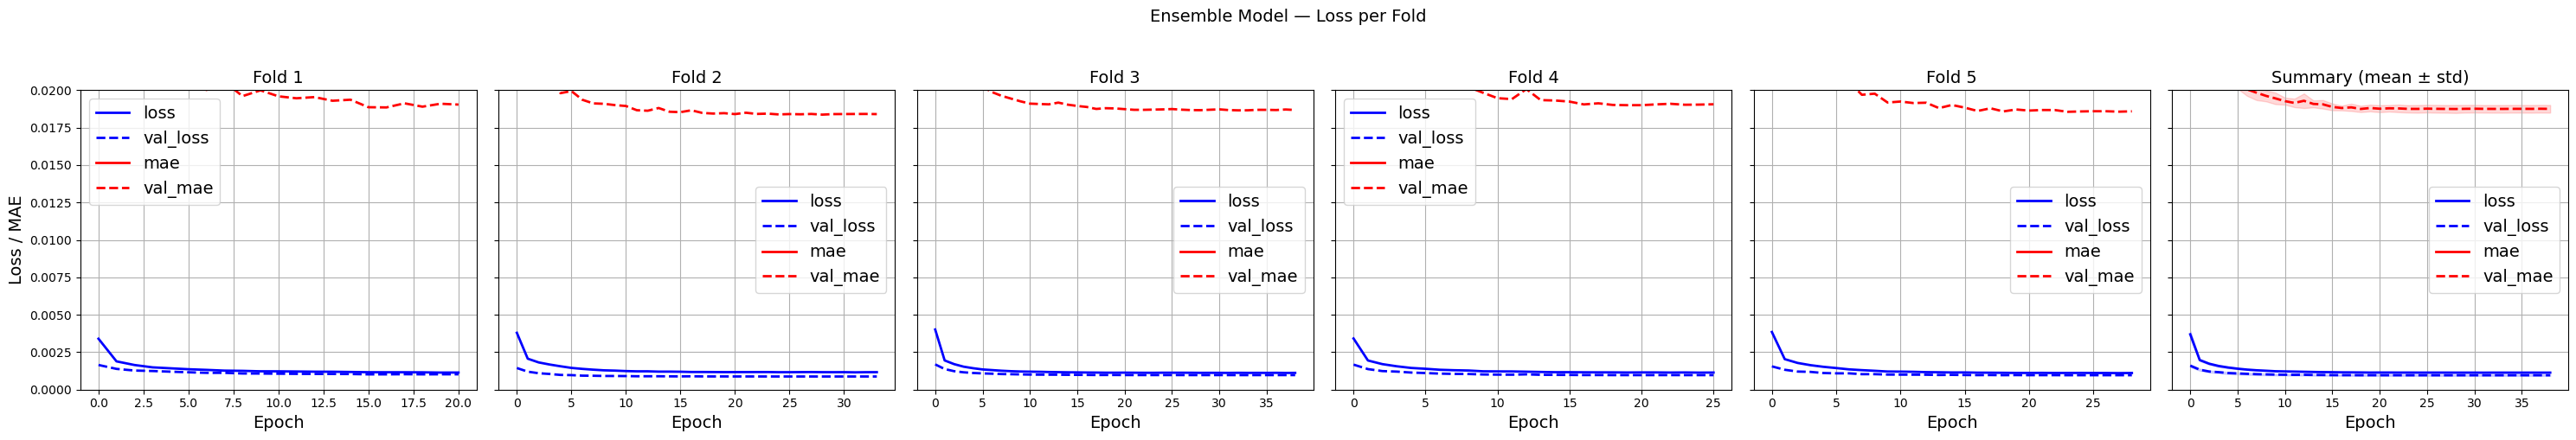

In [102]:
cnnpz.plot_ensemble_losses(histories, ylim=(0, 0.02))

In [103]:
y_pred_ensemble2, y_pred_STD2 = cnnpz.ensemble_predict(trained_models, X)

3125/3125 [==============================] - 3s 1ms/step


In [104]:
# save the trained model:
root = "/pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/Cardinal_Y1/models"
save_dir = root + "/ensemble_CNN_6layers_missing_finetune"
cnnpz.save_ensemble(trained_models, save_dir=save_dir)

Saved fold 1 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/Cardinal_Y1/models/ensemble_CNN_6layers_missing_finetune/model_fold_1.keras
Saved fold 2 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/Cardinal_Y1/models/ensemble_CNN_6layers_missing_finetune/model_fold_2.keras
Saved fold 3 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/Cardinal_Y1/models/ensemble_CNN_6layers_missing_finetune/model_fold_3.keras
Saved fold 4 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/Cardinal_Y1/models/ensemble_CNN_6layers_missing_finetune/model_fold_4.keras
Saved fold 5 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/Cardinal_Y1/models/ensemble_CNN_6layers_missing_finetune/model_fold_5.keras
Saved normalisation parameters to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/Cardinal_Y1/models/ensemble_CNN_6layers_missing_finetune/norm_params.json


In [105]:
y_pred_ensemble, y_pred_STD = cnnpz.ensemble_predict(trained_models, X_test)

625/625 [==============================] - 1s 1ms/step


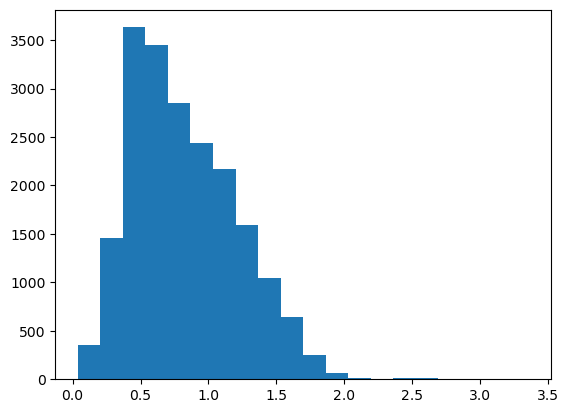

In [106]:
cc = plt.hist(y_pred_ensemble.flatten(), bins=20)

/tmp/ipykernel_1270205/1952338895.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


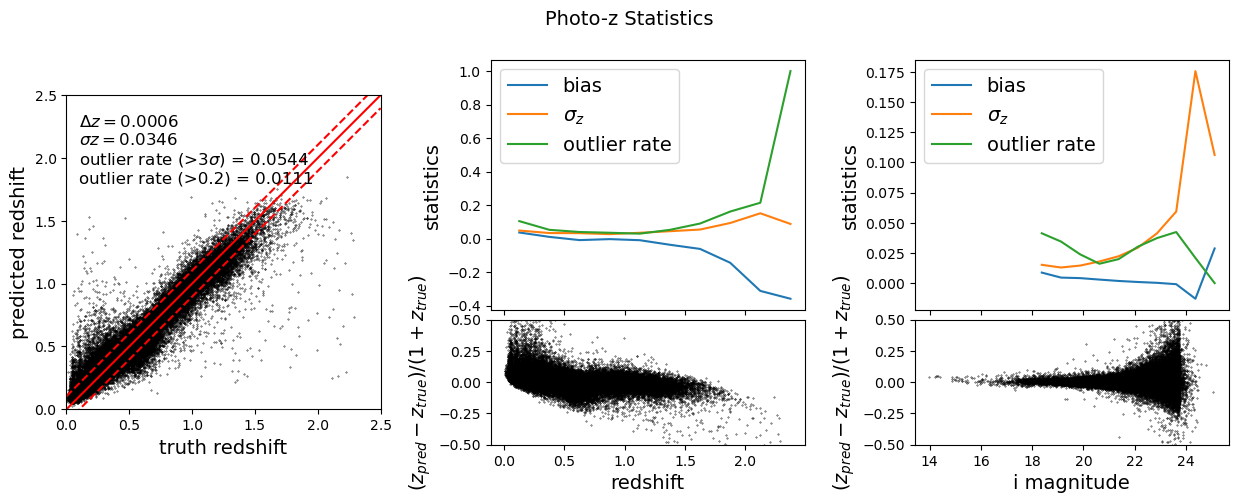

Plot saved to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/Cardinal_Y1/models/ensemble_CNN_6layers_missing_finetune/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [107]:
redshift_bins = np.linspace(0, 2.5, 11)
imag_bins = np.linspace(18, 25.5, 11)
fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = cnnpz.get_all_stats(
    Y,
    y_pred_ensemble2.flatten(),
    training_data["mag_i_lsst"],
    save=True,
    saveroot=fname,
    redshift_bins=redshift_bins,
    imag_bins=imag_bins,
)

cnnpz.plot_stats(
    stats2,
    redshift_stats2,
    imag_stats2,
    Y,
    y_pred_ensemble2.flatten(),
    redshift_bins,
    imag_bins,
    training_data["mag_i_lsst"],
    save_path=save_dir + "/photoz_stats.png",
)

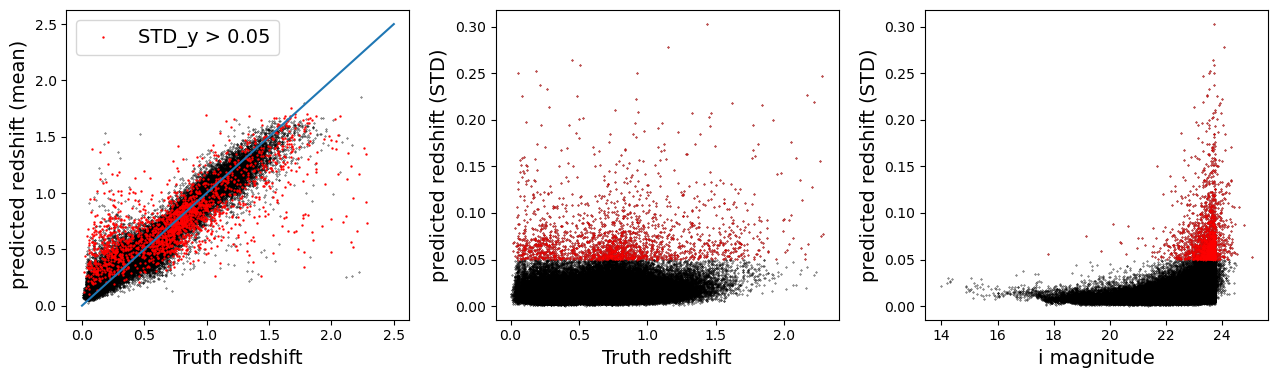

In [108]:
# also plot the STD as a function of redshift and i-band magnitude:
fig, axarr = plt.subplots(1, 3, figsize=[13, 4])
plt.sca(axarr[0])
ind = y_pred_STD2.flatten() >= 0.05
plt.scatter(Y[~ind], y_pred_ensemble2.flatten()[~ind], s=0.1, color="k")
plt.scatter(Y[ind], y_pred_ensemble2.flatten()[ind], s=0.5, color="r", label="STD_y > 0.05")
plt.xlabel("Truth redshift")
plt.ylabel("predicted redshift (mean)")
plt.legend()
plt.plot([0, 2.5], [0, 2.5])

plt.sca(axarr[1])
plt.scatter(Y, y_pred_STD2.flatten(), s=0.1, color="k")
plt.scatter(Y[ind], y_pred_STD2.flatten()[ind], s=0.1, color="r")
plt.xlabel("Truth redshift")
plt.ylabel("predicted redshift (STD)")

plt.sca(axarr[2])
plt.scatter(training_data["mag_i_lsst"], y_pred_STD2.flatten(), s=0.1, color="k")
plt.scatter(training_data["mag_i_lsst"][ind], y_pred_STD2.flatten()[ind], s=0.1, color="r")
plt.xlabel("i magnitude")
plt.ylabel("predicted redshift (STD)")

plt.tight_layout()

## Cardinal Y10

In [40]:
training_data = train_dataset_taskset2["cardinal"][10]
test_data = test_dataset_taskset2["cardinal"][10]

X, Y = cnnpz.transform_data_to_XY(training_data, lambda_array_cen, filter_blocks, apply_stretch=False)
X_test, _ = cnnpz.transform_data_to_XY(test_data, lambda_array_cen, filter_blocks, apply_stretch=False, missingY=True)

In [41]:
# reserve 10% for checking:
rand_mask = np.random.rand(len(Y.to_numpy())) < 0.10
X_fortrain = X[~rand_mask, :, :]
Y_fortrain = Y.to_numpy()[~rand_mask]

X_forval = X[rand_mask, :, :]
Y_forval = Y.to_numpy()[rand_mask]

X_test = np.copy(X_test)

print(len(Y_fortrain), len(Y_forval), len(X_test))

90058 9942 20000


In [ ]:
trained_models, histories = cnnpz.fine_tune_pre_trained_model(
    X_fortrain,
    Y_fortrain,
    model_root="/pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/popcosmos/models/ensemble_CNN_6layers_missing/",
    nlayers_forzen=4,
)

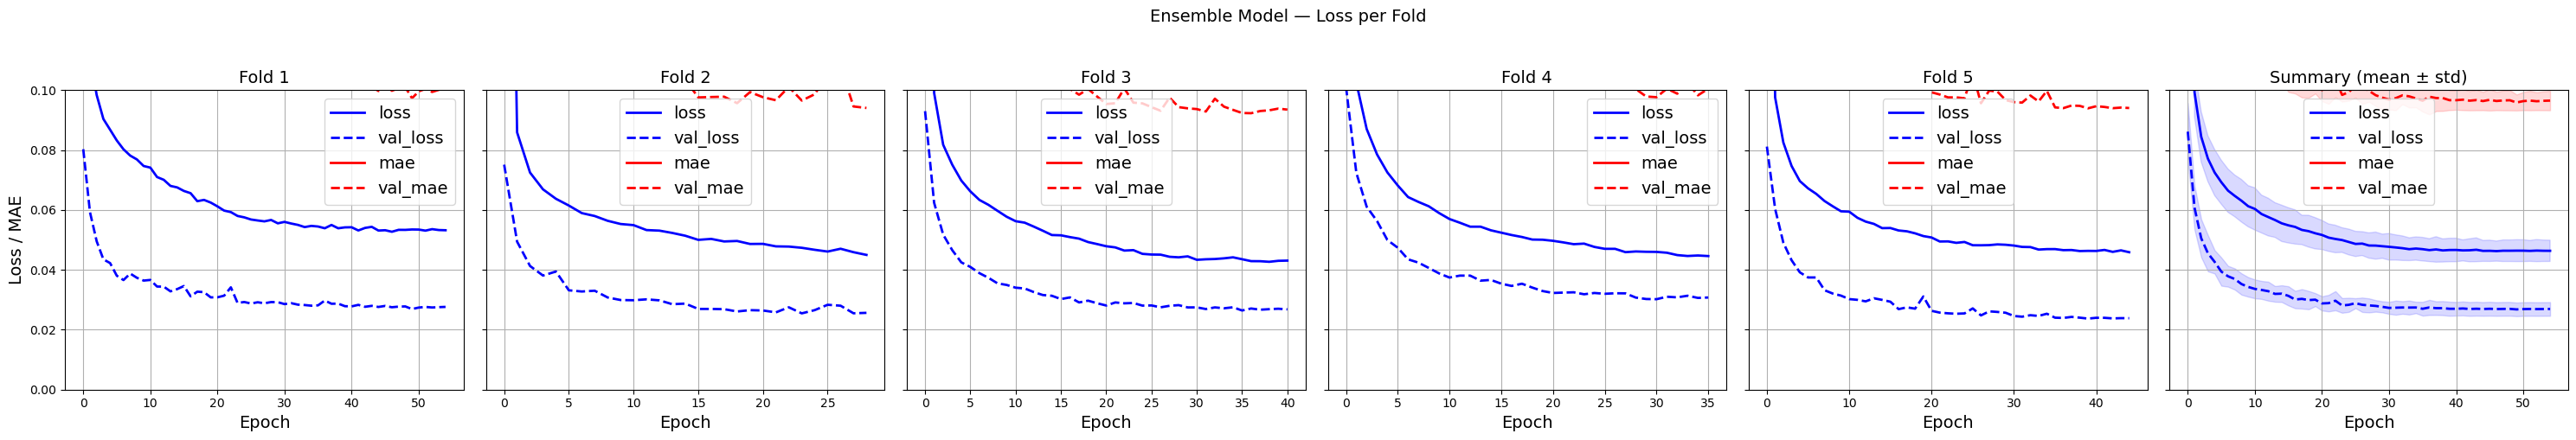

In [114]:
cnnpz.plot_ensemble_losses(histories, ylim=(0, 0.1))

In [115]:
y_pred_ensemble2, y_pred_STD2 = cnnpz.ensemble_predict(trained_models, X_stretch)

3125/3125 [==============================] - 3s 1ms/step


In [116]:
# save the trained model:
root = "/pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/Cardinal_Y10/models"
save_dir = root + "/ensemble_CNN_6layers_missing_finetune"
cnnpz.save_ensemble(trained_models, save_dir=save_dir)

Saved fold 1 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/Cardinal_Y10/models/ensemble_CNN_6layers_missing_finetune/model_fold_1.keras
Saved fold 2 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/Cardinal_Y10/models/ensemble_CNN_6layers_missing_finetune/model_fold_2.keras
Saved fold 3 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/Cardinal_Y10/models/ensemble_CNN_6layers_missing_finetune/model_fold_3.keras
Saved fold 4 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/Cardinal_Y10/models/ensemble_CNN_6layers_missing_finetune/model_fold_4.keras
Saved fold 5 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/Cardinal_Y10/models/ensemble_CNN_6layers_missing_finetune/model_fold_5.keras
Saved normalisation parameters to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/Cardinal_Y10/models/ensemble_CNN_6layers_missing_finetune/norm_params.json


/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/scipy/stats/_stats_py.py:3666: RuntimeWarning: Mean of empty slice.
  c_mean = c.mean()
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global

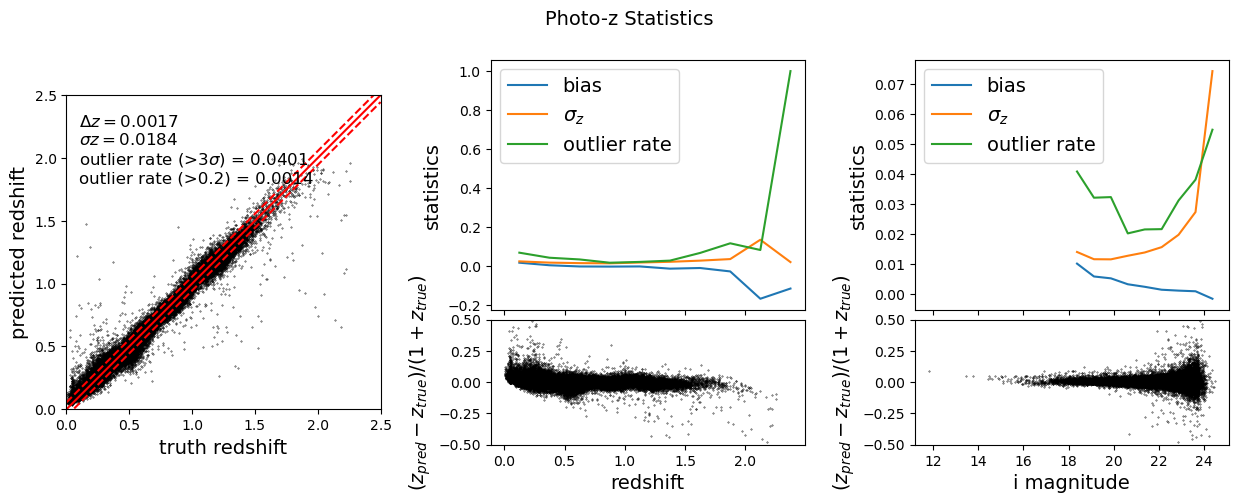

Plot saved to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset2/Cardinal_Y10/models/ensemble_CNN_6layers_missing_finetune/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [117]:
redshift_bins = np.linspace(0, 2.5, 11)
imag_bins = np.linspace(18, 25.5, 11)
fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = cnnpz.get_all_stats(
    Y,
    y_pred_ensemble2.flatten(),
    training_data["mag_i_lsst"],
    save=True,
    saveroot=fname,
    redshift_bins=redshift_bins,
    imag_bins=imag_bins,
)

cnnpz.plot_stats(
    stats2,
    redshift_stats2,
    imag_stats2,
    Y,
    y_pred_ensemble2.flatten(),
    redshift_bins,
    imag_bins,
    training_data["mag_i_lsst"],
    save_path=save_dir + "/photoz_stats.png",
)

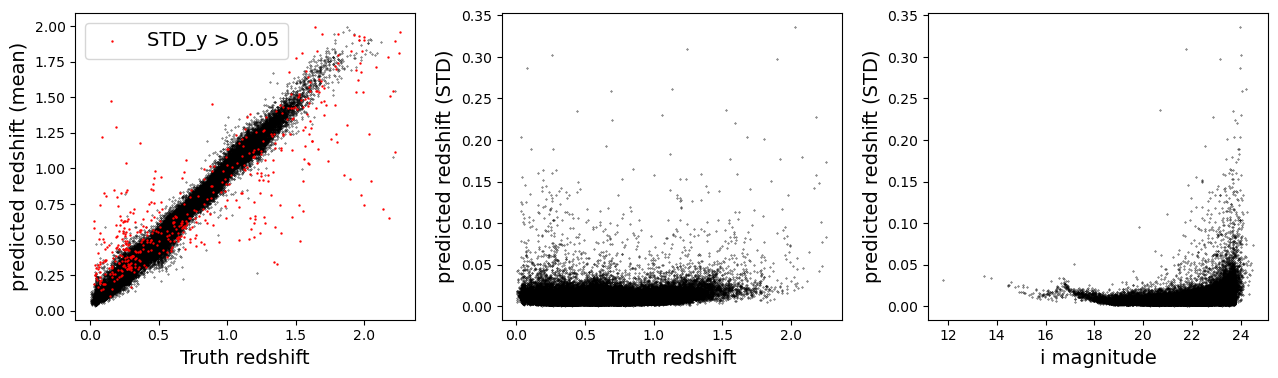

In [118]:
# also plot the STD as a function of redshift and i-band magnitude:
fig, axarr = plt.subplots(1, 3, figsize=[13, 4])
plt.sca(axarr[0])
ind = y_pred_STD2.flatten() >= 0.05
plt.scatter(Y[~ind], y_pred_ensemble2.flatten()[~ind], s=0.1, color="k")
plt.scatter(Y[ind], y_pred_ensemble2.flatten()[ind], s=0.5, color="r", label="STD_y > 0.05")
plt.xlabel("Truth redshift")
plt.ylabel("predicted redshift (mean)")
plt.legend()

plt.sca(axarr[1])
plt.scatter(Y, y_pred_STD2.flatten(), s=0.1, color="k")
plt.xlabel("Truth redshift")
plt.ylabel("predicted redshift (STD)")

plt.sca(axarr[2])
plt.scatter(training_data["mag_i_lsst"], y_pred_STD2.flatten(), s=0.1, color="k")
plt.xlabel("i magnitude")
plt.ylabel("predicted redshift (STD)")

plt.tight_layout()

In [119]:
y_pred_ensemble, y_pred_STD = cnnpz.ensemble_predict(trained_models, X_test_stretch)

625/625 [==============================] - 1s 1ms/step


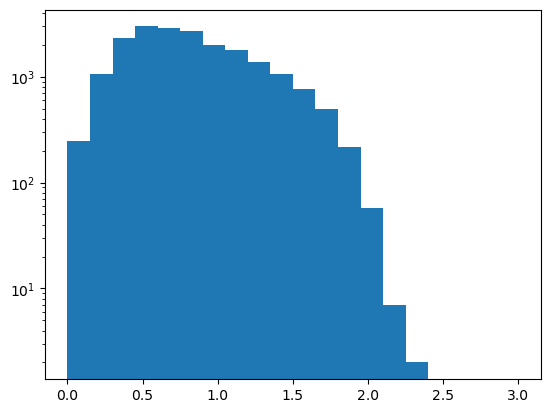

In [122]:
cc = plt.hist(y_pred_ensemble.flatten(), bins=20, range=[0, 3])
plt.yscale("log")

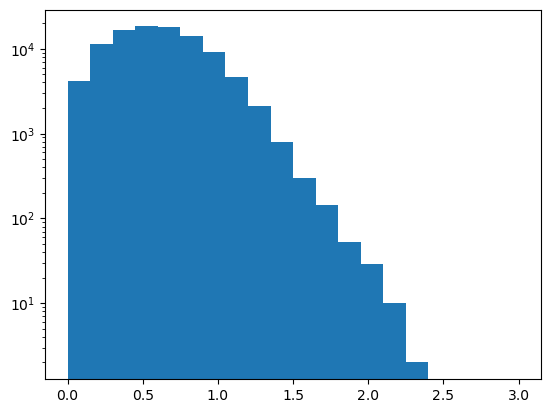

In [125]:
cc = plt.hist(Y, bins=20, range=[0, 3])
plt.yscale("log")

# flagship